Loading data...
Loaded 500000 rows
Training records: 22778

Training Random Forest Regressor...

=== REGRESSION PERFORMANCE ===
MSE: 105377.99
MAE: 149.75
R²: 0.402

Top Predictors of App Crashes:
                  feature  importance
4             uptime_days    0.398184
2               cpu_count    0.222365
1  avg_memory_utilization    0.180053
0           max_cpu_usage    0.093616
5            avg_cpu_temp    0.092204

=== HIGH APP CRASH RISK DETECTION ===
Threshold: 795 crashes
Detection Accuracy: 0.903


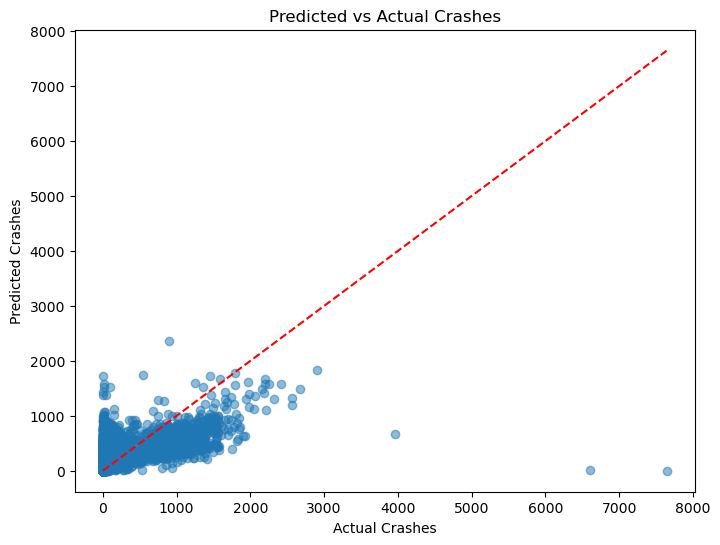

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- issue


In [ ]:
#UPTIME DAYS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import gzip
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")

columns = [
    'karl_id', 'host_name', 'model_name', 'hardware_make', 'karl_last_seen',
    'auth_username', 'serial_number', 'group_id', 'tenant_id', 'platform',
    'metric_category', 'measure_name', 'time', 'p90_processor_time',
    'avg_processor_time', 'max_cpu_usage', 'p90_memory_utilization',
    'avg_memory_utilization', 'max_memory_usage', 'p10_battery_health',
    'avg_battery_health', 'cpu_count', 'memory_count', 'memory_size_gb',
    'driver_vendor', 'os', 'wifi_mac_add', 'driver_version', 'driver_date',
    'os_version', 'driver', 'agent_id', 'performance_status', 'device_status',
    'max_battery_temperature', 'avg_battery_temperature', 'p90_battery_temperature',
    'avg_cpu_temp', 'p90_cpu_temp', 'avg_battery_discharge', 'p90_battery_discharge',
    'avg_boot_time', 'p90_boot_time', 'uptime_days', 'total_app_crash'
]

# Load sample
chunk_size = 100000
sample_data = []
with gzip.open('000.gz', 'rt') as f:
    for i, chunk in enumerate(pd.read_csv(f, sep='|', names=columns, chunksize=chunk_size)):
        sample_data.append(chunk)
        if i >= 4:
            break

df = pd.concat(sample_data, ignore_index=True)

numeric_cols = [
    'avg_processor_time', 'max_cpu_usage', 'avg_memory_utilization',
    'max_memory_usage', 'avg_battery_health', 'cpu_count', 'memory_size_gb',
    'avg_cpu_temp', 'avg_boot_time', 'p90_boot_time',
    'uptime_days', 'total_app_crash'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Loaded {len(df)} rows")

# narrow down
feature_cols = ['max_cpu_usage', 'avg_memory_utilization', 'cpu_count', 'memory_size_gb', 'uptime_days', 'avg_cpu_temp']

def diagnose_issue(row):
    if row["max_cpu_usage"] > 10 and row["max_cpu_usage"] < 15:
        return "Thermal/CPU Issue"
    elif row['avg_memory_utilization'] > 50 or row['avg_memory_utilization'] < 65:
        return "Memory Pressure"
    elif row['cpu_count'] > 6500 or row['cpu_count'] < 7250:
        return "Thermal/CPU Issue"
    elif row['avg_cpu_temp'] > 50 or row['avg_cpu_temp'] < 75:
        return "Thermal/CPU Issue"
    elif row['memory_size_gb'] >= 16 or row['memory_size_gb'] <= 18:
        return "Memory Pressure"
    elif row['uptime_days'] >= 26 or row['uptime_days'] <= 28:
        return "Needs Restart / Stability Issue"
    else:
        return "Visit ITSE"


model_df = df[feature_cols + ['total_app_crash']].dropna()
model_df = model_df[model_df['total_app_crash'] > 0]

print(f"Training records: {len(model_df)}")

X = model_df[feature_cols]
y = model_df['total_app_crash']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Training model
print("\nTraining Random Forest Regressor...")

rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== REGRESSION PERFORMANCE ===")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

#Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop Predictors of App Crashes:")
print(importance.head())

#Risk threshold and accuracy
risk_threshold = model_df['total_app_crash'].quantile(0.90)
actual_high_risk = y_test >= risk_threshold
pred_high_risk = y_pred >= risk_threshold
risk_accuracy = (actual_high_risk == pred_high_risk).mean()

print("\n=== HIGH APP CRASH RISK DETECTION ===")
print(f"Threshold: {risk_threshold:.0f} crashes")
print(f"Detection Accuracy: {risk_accuracy:.3f}")

#Visualizing
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Crashes")
plt.ylabel("Predicted Crashes")
plt.title("Predicted vs Actual Crashes")
plt.show()

new_host_values = {
    'max_cpu_usage': 92,
    'avg_memory_utilization': 95,
    'cpu_count': 8,
    'memory_size_gb': 16,
    'avg_cpu_temp': 100,
    'uptime_days': 50
}


new_host = pd.DataFrame([new_host_values])
new_host = new_host[feature_cols]

new_host['issue'] = new_host.apply(diagnose_issue, axis=1)

prediction = rf_model.predict(new_host)[0]

print(f"Predicted crashes: {prediction:.2f}")